# Exploratory Data Analysis — Aggregated FCR-D Participation for BTM Energy Communities

This notebook provides an initial exploration of the datasets underpinning the study.
We walk through each data source, surface key patterns, and build intuition for the dynamics that the optimisation model must navigate.

**Datasets covered:**
1. **Energy Community metering data** — cumulative consumption & PV production from residential buildings
2. **Spot & Day-Ahead electricity prices** — DK2 price area, 2025
3. **FCR-D ancillary-service auction prices** — up/down regulation, early/late auctions, DK2 2025

## 1 — Setup & colour palette

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings, calendar
warnings.filterwarnings('ignore')

# ── Palette ──────────────────────────────────────────────
# Thesis accent colours (for reference, NOT used here):
#   #FFCC00  #00BDF2  #F42CFF
# Complementary palette for this notebook:
PAL = {
    'teal':     '#0D7C66',
    'coral':    '#E05D44',
    'slate':    '#4A6FA5',
    'plum':     '#8E5572',
    'amber':    '#D4A029',
    'stone':    '#6B7F82',
}
C = list(PAL.values())

# Plot style
plt.rcParams.update({
    'figure.facecolor':   'white',
    'axes.facecolor':     '#FAFAFA',
    'axes.edgecolor':     '#CCCCCC',
    'axes.grid':          True,
    'grid.color':         '#E5E5E5',
    'grid.linewidth':     0.6,
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'figure.dpi':         130,
    'savefig.dpi':        200,
    'legend.framealpha':  0.85,
    'legend.edgecolor':   '#CCCCCC',
})

print("Setup complete ✓")


Setup complete ✓


## 2 — Data loading & initial cleaning

All raw files are loaded and parsed here. Decimal separators, timestamps and filtering to the DK2 price area are handled in one pass.

In [11]:
# ── 2.1  Energy community metering data ──────────────────
ec_raw = pd.read_csv('data_ec/s_data.csv')
ec_raw['reading_time'] = pd.to_datetime(ec_raw['reading_time'])
ec_raw = ec_raw.drop(columns=['Unnamed: 0'])

# Separate PV production (Serial == -2) from consumption meters
pv_raw = ec_raw[ec_raw['Serial'] == -2].copy()
cons_raw = ec_raw[ec_raw['Serial'] != -2].copy()

n_cons_meters = cons_raw['Serial'].nunique()
print(f"Consumption meters : {n_cons_meters}")
print(f"PV production meter: Serial -2")
print(f"Total rows         : {len(ec_raw):,}")
print(f"Date range         : {ec_raw['reading_time'].min()} → {ec_raw['reading_time'].max()}")


Consumption meters : 62
PV production meter: Serial -2
Total rows         : 547,852
Date range         : 2025-01-01 00:00:00 → 2026-01-01 00:00:00


In [12]:
# ── 2.2  Spot prices (hourly, Jan-Sep 2025) ──────────────
spot_raw = pd.read_csv('data_spot/Elspotprices.csv', sep=';')
for col in ['SpotPriceDKK', 'SpotPriceEUR']:
    spot_raw[col] = spot_raw[col].str.replace(',', '.').astype(float)
spot_raw['HourDK'] = pd.to_datetime(spot_raw['HourDK'])
spot_dk2 = spot_raw[spot_raw['PriceArea'] == 'DK2'].copy()
spot_dk2 = spot_dk2.set_index('HourDK').sort_index()

# ── 2.3  Day-Ahead prices (15-min, Oct-Dec 2025) ────────
da_raw = pd.read_csv('data_spot/DayAheadPrices.csv', sep=';')
for col in ['DayAheadPriceEUR', 'DayAheadPriceDKK']:
    da_raw[col] = da_raw[col].str.replace(',', '.').astype(float)
da_raw['TimeDK'] = pd.to_datetime(da_raw['TimeDK'])
da_raw = da_raw.set_index('TimeDK').sort_index()
# Average to hourly to match first half
da_hourly = da_raw[['DayAheadPriceEUR', 'DayAheadPriceDKK']].resample('h').mean()
da_hourly = da_hourly.rename(columns={
    'DayAheadPriceDKK': 'SpotPriceDKK',
    'DayAheadPriceEUR': 'SpotPriceEUR'
})

# ── Combine into one full-year spot series ───────────────
spot_full = pd.concat([
    spot_dk2[['SpotPriceDKK', 'SpotPriceEUR']],
    da_hourly[['SpotPriceDKK', 'SpotPriceEUR']]
]).sort_index()
spot_full = spot_full[~spot_full.index.duplicated(keep='first')]
spot_full = spot_full.loc['2025']

print(f"Spot price series  : {len(spot_full):,} hours")
print(f"Date range         : {spot_full.index.min()} → {spot_full.index.max()}")
print(f"Price DKK — mean {spot_full['SpotPriceDKK'].mean():.1f}, "
      f"median {spot_full['SpotPriceDKK'].median():.1f}, "
      f"std {spot_full['SpotPriceDKK'].std():.1f}")


Spot price series  : 8,759 hours
Date range         : 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Price DKK — mean 615.8, median 639.8, std 386.5


In [13]:
# ── 2.4  FCR-D auction data ───────────────────────────────
fcrd_raw = pd.read_csv('data_FCRD/FcrNdDK2.csv', sep=';')
for col in ['PurchasedVolumeLocal', 'PurchasedVolumeTotal', 'PriceTotalEUR']:
    fcrd_raw[col] = fcrd_raw[col].str.replace(',', '.').astype(float)
fcrd_raw['HourDK'] = pd.to_datetime(fcrd_raw['HourDK'])
fcrd = fcrd_raw.set_index('HourDK').sort_index()
fcrd = fcrd.loc['2025']

products = fcrd['ProductName'].unique().tolist()
auctions = fcrd['AuctionType'].unique().tolist()
print(f"FCR-D rows (2025)  : {len(fcrd):,}")
print(f"Products           : {products}")
print(f"Auction types      : {auctions}")


FCR-D rows (2025)  : 78,840
Products           : ['FCR-N', 'FCR-D upp', 'FCR-D ned']
Auction types      : ['D-1 early', 'Total', 'D-1 late']


---
## 3 — Energy community: consumption & PV production

The raw data is **cumulative** meter readings at roughly hourly intervals.
We difference them to obtain per-hour consumption (kWh/h) and PV production, then aggregate across all meters in the community.

In [14]:
# ── Convert cumulative → hourly for each serial ─────────
def cumulative_to_hourly(df, value_col='Consumption'):
    # For each serial: resample cumulative to hourly, interpolate, difference
    records = []
    for serial, grp in df.groupby('Serial'):
        s = grp.set_index('reading_time')[value_col].sort_index()
        s = s[~s.index.duplicated(keep='first')]
        s = s.resample('h').mean().interpolate(method='linear')
        delta = s.diff().dropna()
        delta = delta.clip(lower=0)
        delta.name = 'kWh'
        records.append(delta.to_frame().assign(Serial=serial))
    return pd.concat(records)

cons_hourly = cumulative_to_hourly(cons_raw)
pv_hourly   = cumulative_to_hourly(pv_raw)

# Aggregate across all meters → community level
community_demand = cons_hourly.groupby(cons_hourly.index)['kWh'].sum()
community_pv     = pv_hourly.groupby(pv_hourly.index)['kWh'].sum()

# Keep only 2025
community_demand = community_demand.loc['2025']
community_pv     = community_pv.loc['2025']

print(f"Community demand : {len(community_demand):,} hours, total {community_demand.sum():,.0f} kWh")
print(f"Community PV     : {len(community_pv):,} hours, total {community_pv.sum():,.0f} kWh")


Community demand : 8,759 hours, total 105,955 kWh
Community PV     : 8,758 hours, total 47,952 kWh


### 3.1 — Full-year demand & PV production profiles

The plot below shows the aggregate hourly demand and PV generation across all meters for the entire year.
Note the strong **seasonality** in PV — nearly zero in winter months, peaking in summer — and the relatively stable but noisy demand pattern.

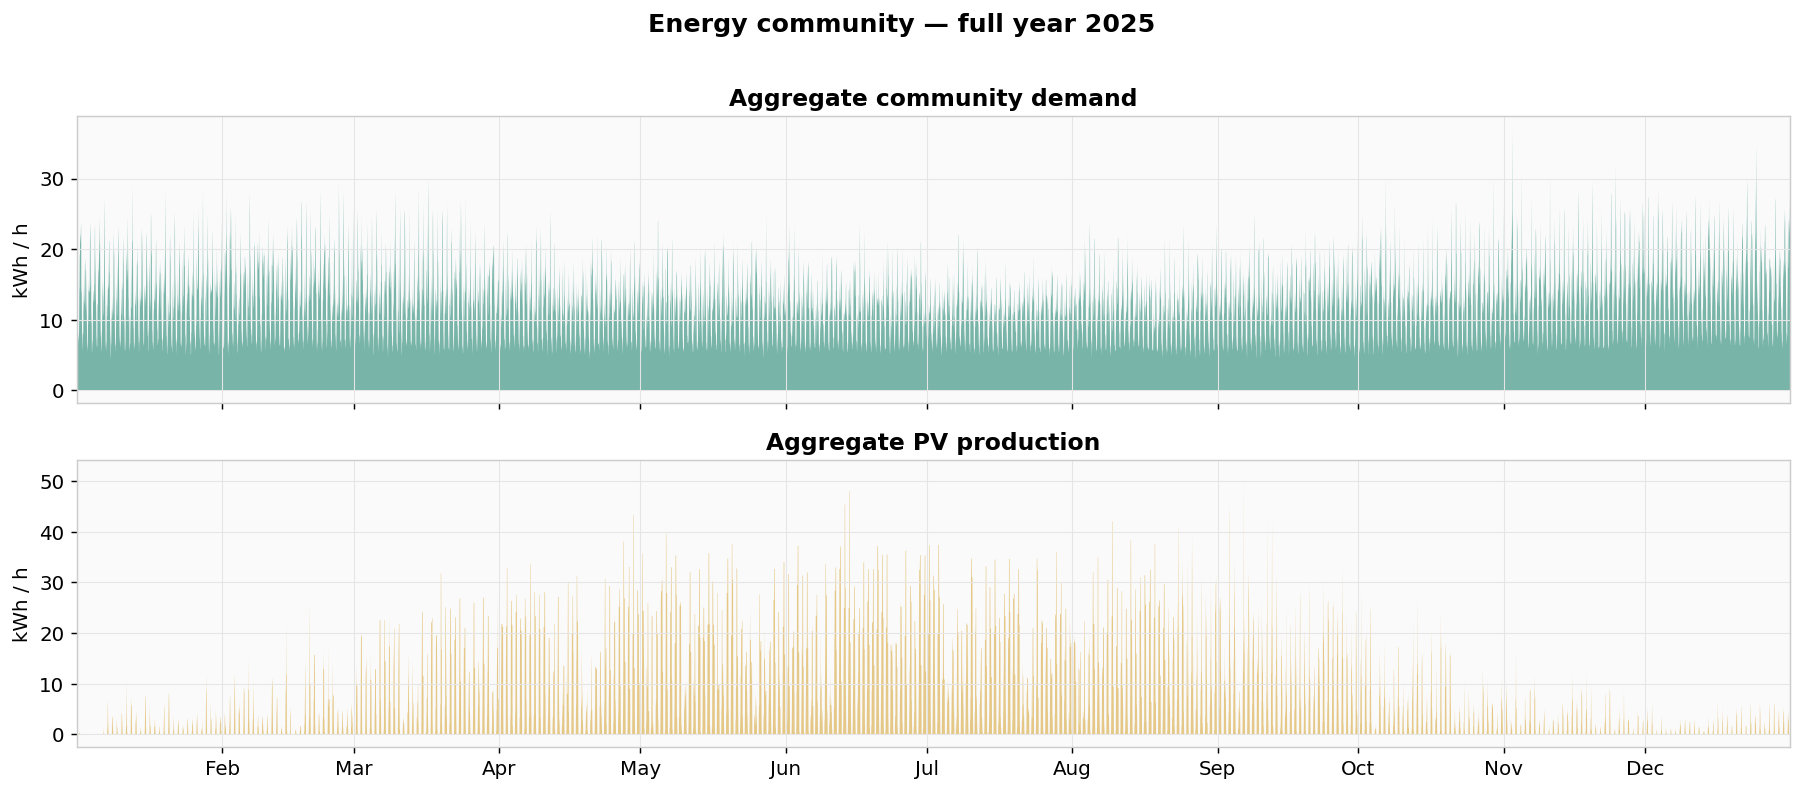

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].fill_between(community_demand.index, community_demand.values,
                     alpha=0.55, color=C[0], linewidth=0)
axes[0].set_ylabel('kWh / h')
axes[0].set_title('Aggregate community demand')

axes[1].fill_between(community_pv.index, community_pv.values,
                     alpha=0.55, color=C[4], linewidth=0)
axes[1].set_ylabel('kWh / h')
axes[1].set_title('Aggregate PV production')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.margins(x=0)

fig.suptitle('Energy community — full year 2025', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 3.2 — Average daily load profile by season

Residential electricity demand follows a strong diurnal cycle.
We expect a **morning bump** and a pronounced **evening peak around 17–20h** when occupants return home.

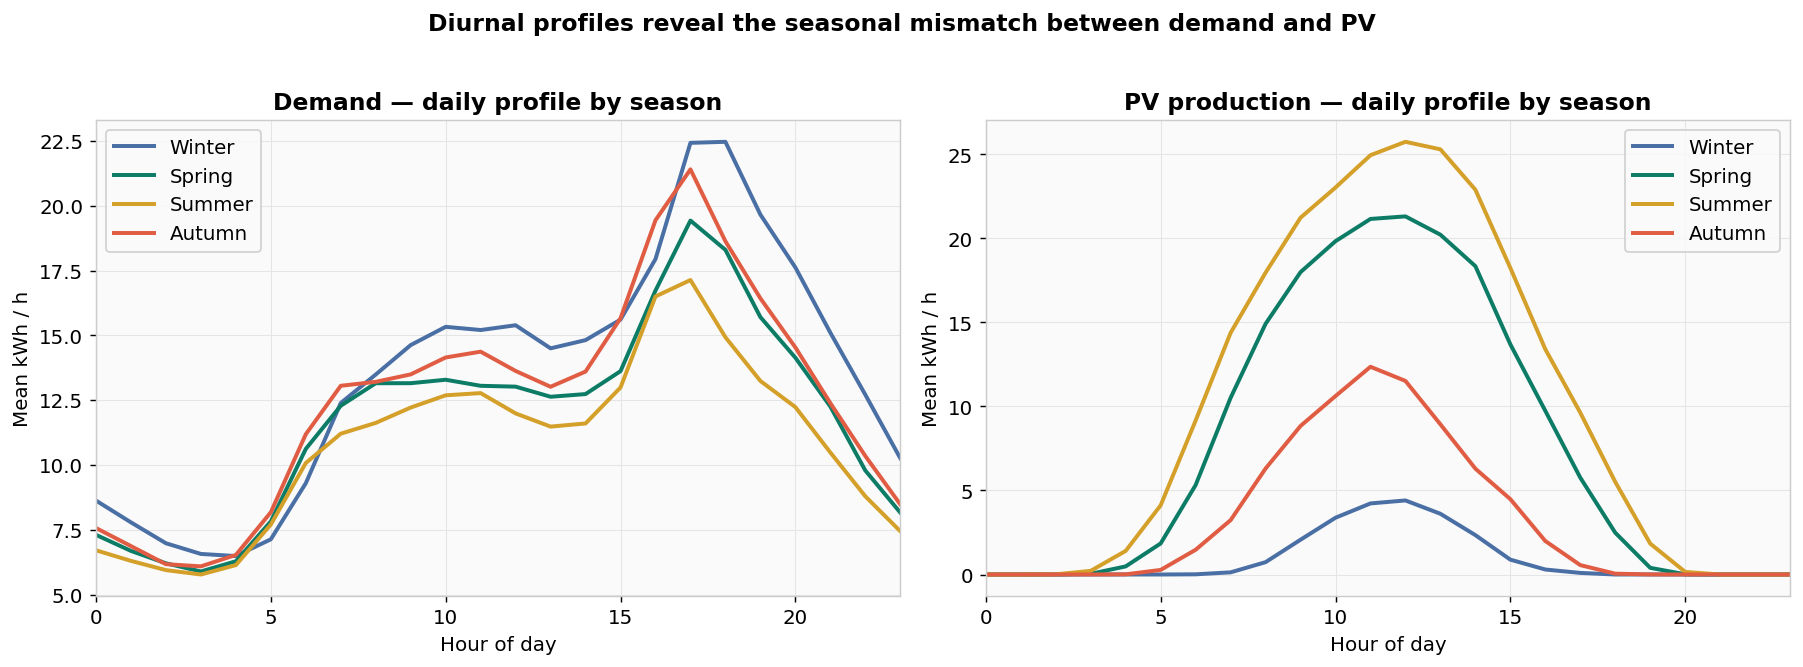

In [16]:
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    if month in [3, 4, 5]:   return 'Spring'
    if month in [6, 7, 8]:   return 'Summer'
    return 'Autumn'

demand_df = community_demand.to_frame('kWh')
demand_df['hour'] = demand_df.index.hour
demand_df['season'] = demand_df.index.month.map(get_season)

pv_df = community_pv.to_frame('kWh')
pv_df['hour'] = pv_df.index.hour
pv_df['season'] = pv_df.index.month.map(get_season)

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {
    'Winter': C[2],
    'Spring': C[0],
    'Summer': C[4],
    'Autumn': C[1],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s in season_order:
    profile = demand_df[demand_df['season'] == s].groupby('hour')['kWh'].mean()
    axes[0].plot(profile.index, profile.values, label=s,
                 color=season_colors[s], linewidth=2.2)
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Mean kWh / h')
axes[0].set_title('Demand — daily profile by season')
axes[0].legend()
axes[0].set_xlim(0, 23)

for s in season_order:
    profile = pv_df[pv_df['season'] == s].groupby('hour')['kWh'].mean()
    axes[1].plot(profile.index, profile.values, label=s,
                 color=season_colors[s], linewidth=2.2)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean kWh / h')
axes[1].set_title('PV production — daily profile by season')
axes[1].legend()
axes[1].set_xlim(0, 23)

fig.suptitle('Diurnal profiles reveal the seasonal mismatch between demand and PV',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


### 3.3 — Net load (demand minus PV)

The **net load** determines when the community needs to import from the grid and when it can export surplus PV.
Negative net load = export opportunity. This is directly relevant for battery scheduling and FCR-D participation.

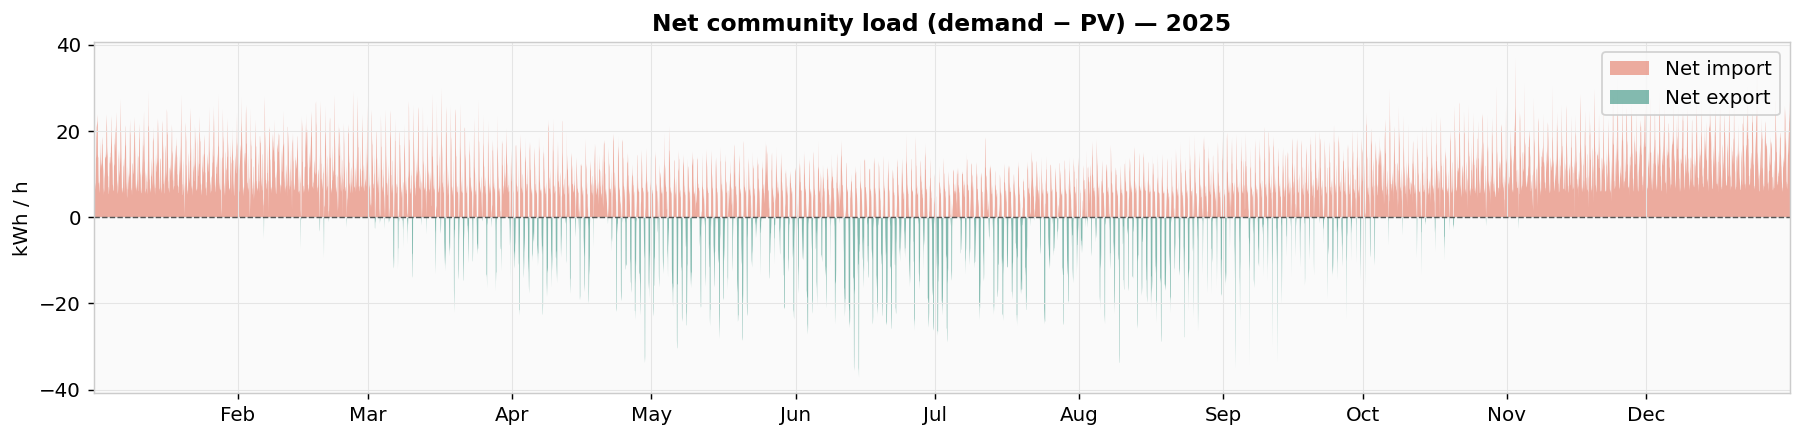

Hours with surplus PV (net export): 1550 / 8758 (17.7%)


In [17]:
net = community_demand.reindex(community_pv.index)
net_load = (net - community_pv).dropna()

fig, ax = plt.subplots(figsize=(14, 3.5))

pos = net_load.clip(lower=0)
neg = net_load.clip(upper=0)

ax.fill_between(net_load.index, pos, alpha=0.5, color=C[1], label='Net import', linewidth=0)
ax.fill_between(net_load.index, neg, alpha=0.5, color=C[0], label='Net export', linewidth=0)
ax.axhline(0, color='#555', linewidth=0.8, linestyle='--')
ax.set_ylabel('kWh / h')
ax.set_title('Net community load (demand − PV) — 2025', fontweight='bold')
ax.legend(loc='upper right')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.margins(x=0)
fig.tight_layout()
plt.show()

export_hours = (net_load < 0).sum()
total_hours = len(net_load)
print(f"Hours with surplus PV (net export): {export_hours} / {total_hours} "
      f"({100*export_hours/total_hours:.1f}%)")


### 3.4 — Weekly heatmap of demand

A heatmap of average demand by hour-of-day and day-of-week surfaces the **double cyclicality**: intra-day and intra-week.

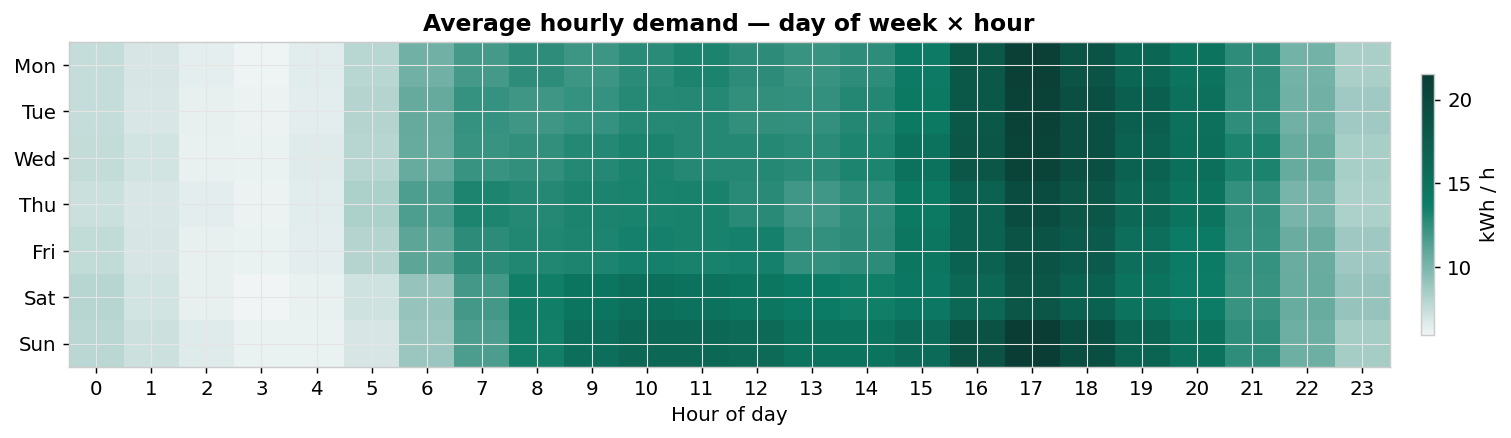

In [18]:
demand_df['dow'] = demand_df.index.dayofweek
pivot = demand_df.groupby(['dow', 'hour'])['kWh'].mean().unstack('hour')
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(13, 3.5))
cmap = LinearSegmentedColormap.from_list('custom', ['#F0F4F5', C[0], '#0A3D33'])
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, interpolation='nearest')
ax.set_xticks(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Hour of day')
ax.set_title('Average hourly demand — day of week × hour', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('kWh / h')
fig.tight_layout()
plt.show()


### 3.5 — Monthly statistics summary

In [19]:
demand_df['month'] = demand_df.index.month
monthly = demand_df.groupby('month')['kWh'].agg(['sum', 'mean', 'std', 'max'])
monthly.columns = ['Total kWh', 'Mean kWh/h', 'Std kWh/h', 'Peak kWh/h']
monthly.index = [calendar.month_abbr[m] for m in monthly.index]

pv_df['month'] = pv_df.index.month
monthly_pv = pv_df.groupby('month')['kWh'].agg(['sum', 'mean', 'max'])
monthly_pv.columns = ['PV Total kWh', 'PV Mean kWh/h', 'PV Peak kWh/h']
monthly_pv.index = [calendar.month_abbr[m] for m in monthly_pv.index]

summary = pd.concat([monthly, monthly_pv], axis=1)
display(summary.round(1))


,Total kWh,Mean kWh/h,Std kWh/h,Peak kWh/h,PV Total kWh,PV Mean kWh/h,PV Peak kWh/h
Jan,9456.1,12.7,5.0,29.1,461.9,0.6,12.2
Feb,8852.3,13.2,5.2,29.3,1127.3,1.7,25.8
Mar,9340.5,12.6,5.0,30.0,3904.2,5.2,31.9
Apr,8263.4,11.5,4.1,25.7,5799.4,8.1,43.4
May,8388.1,11.3,4.0,25.0,7236.0,9.7,39.7
Jun,7941.9,11.0,3.8,23.8,8211.8,11.4,48.1
Jul,7750.3,10.4,3.3,22.1,7173.7,9.6,37.5
Aug,8069.3,10.8,3.9,24.0,6624.8,8.9,42.2
Sep,8355.9,11.6,4.3,25.2,4419.5,6.1,51.6
Oct,9062.4,12.2,4.7,30.3,1870.9,2.5,28.9


---
## 4 — Electricity spot prices (DK2)

The spot price drives the economic case for shifting consumption.
We combine the hourly NordPool series (Jan–Sep) with the 15-minute Day-Ahead series (Oct–Dec, averaged to hourly).

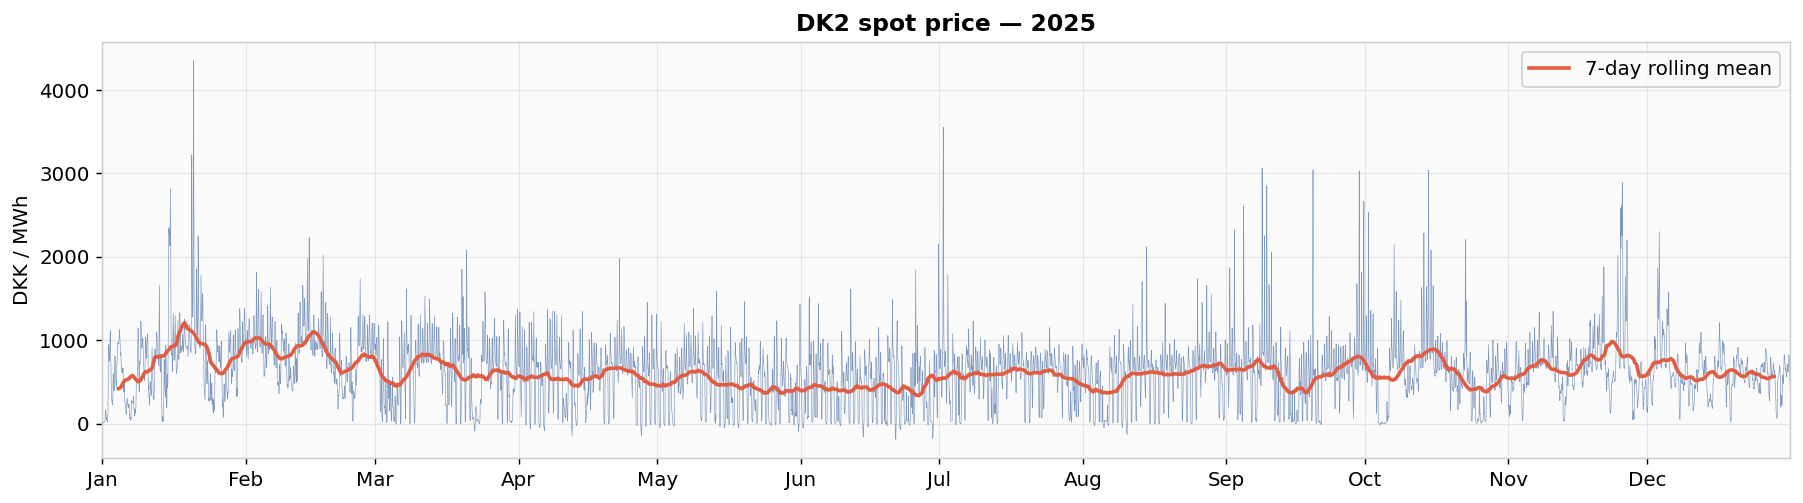

Mean   :    615.8 DKK/MWh
Median :    639.8 DKK/MWh
Std    :    386.5 DKK/MWh
Min    :   -189.1 DKK/MWh
Max    :   4352.7 DKK/MWh
Negative price hours: 265 (3.0%)


In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spot_full.index, spot_full['SpotPriceDKK'], color=C[2],
        linewidth=0.35, alpha=0.7)

monthly_avg = spot_full['SpotPriceDKK'].rolling(24*7, center=True).mean()
ax.plot(monthly_avg.index, monthly_avg.values, color=C[1],
        linewidth=2, label='7-day rolling mean')

ax.set_ylabel('DKK / MWh')
ax.set_title('DK2 spot price — 2025', fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.margins(x=0)
fig.tight_layout()
plt.show()

print(f"Mean   : {spot_full['SpotPriceDKK'].mean():>8.1f} DKK/MWh")
print(f"Median : {spot_full['SpotPriceDKK'].median():>8.1f} DKK/MWh")
print(f"Std    : {spot_full['SpotPriceDKK'].std():>8.1f} DKK/MWh")
print(f"Min    : {spot_full['SpotPriceDKK'].min():>8.1f} DKK/MWh")
print(f"Max    : {spot_full['SpotPriceDKK'].max():>8.1f} DKK/MWh")
neg_hours = (spot_full['SpotPriceDKK'] < 0).sum()
print(f"Negative price hours: {neg_hours} ({100*neg_hours/len(spot_full):.1f}%)")


### 4.1 — Spot price distribution

Spot prices exhibit heavy tails. A few extreme hours dominate the economics, which is why flexible assets (batteries, demand response) capture outsized value.

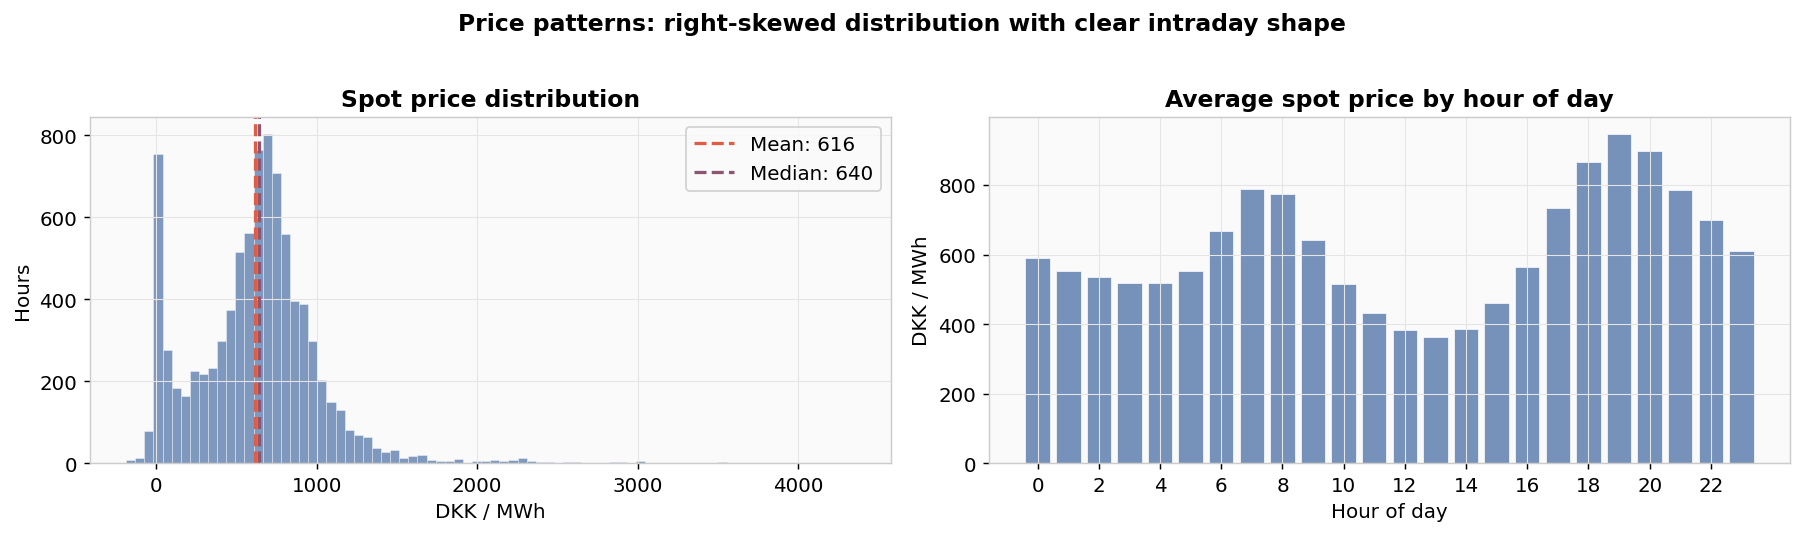

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(spot_full['SpotPriceDKK'], bins=80, color=C[2], alpha=0.7,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(spot_full['SpotPriceDKK'].mean(), color=C[1], linewidth=1.8,
                linestyle='--', label=f"Mean: {spot_full['SpotPriceDKK'].mean():.0f}")
axes[0].axvline(spot_full['SpotPriceDKK'].median(), color=C[3], linewidth=1.8,
                linestyle='--', label=f"Median: {spot_full['SpotPriceDKK'].median():.0f}")
axes[0].set_xlabel('DKK / MWh')
axes[0].set_ylabel('Hours')
axes[0].set_title('Spot price distribution')
axes[0].legend()

hourly_price = spot_full.copy()
hourly_price['hour'] = hourly_price.index.hour
avg_by_hour = hourly_price.groupby('hour')['SpotPriceDKK'].mean()
axes[1].bar(avg_by_hour.index, avg_by_hour.values, color=C[2], alpha=0.75,
            edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('DKK / MWh')
axes[1].set_title('Average spot price by hour of day')
axes[1].set_xticks(range(0, 24, 2))

fig.suptitle('Price patterns: right-skewed distribution with clear intraday shape',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


### 4.2 — Spot price seasonality

Monthly boxplots reveal how price levels and volatility shift across the year.

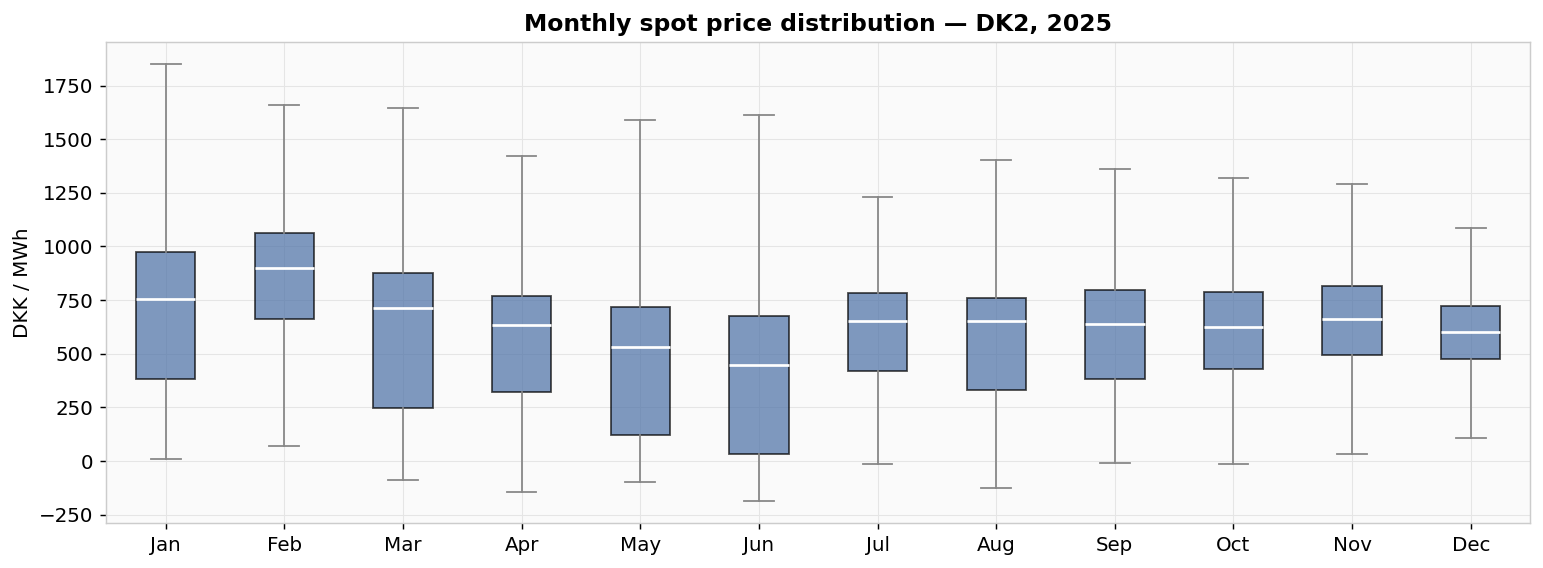

In [22]:
price_monthly = spot_full.copy()
price_monthly['month'] = price_monthly.index.month
months_present = sorted(price_monthly['month'].unique())

data_by_month = [price_monthly[price_monthly['month'] == m]['SpotPriceDKK'].values
                 for m in months_present]
labels = [calendar.month_abbr[m] for m in months_present]

fig, ax = plt.subplots(figsize=(12, 4.5))
bp = ax.boxplot(data_by_month, labels=labels, patch_artist=True, showfliers=False,
                medianprops=dict(color='white', linewidth=1.5),
                whiskerprops=dict(color='#888'),
                capprops=dict(color='#888'))
for patch in bp['boxes']:
    patch.set_facecolor(C[2])
    patch.set_alpha(0.7)
ax.set_ylabel('DKK / MWh')
ax.set_title('Monthly spot price distribution — DK2, 2025', fontweight='bold')
fig.tight_layout()
plt.show()


---
## 5 — FCR-D ancillary service auction prices

FCR-D (Frequency Containment Reserve — Disturbance) is the revenue stream that makes battery participation in energy communities economically interesting.
We explore prices for **up-regulation** (FCR-D upp) and **down-regulation** (FCR-D ned), split by **early** and **late** D-1 auctions.

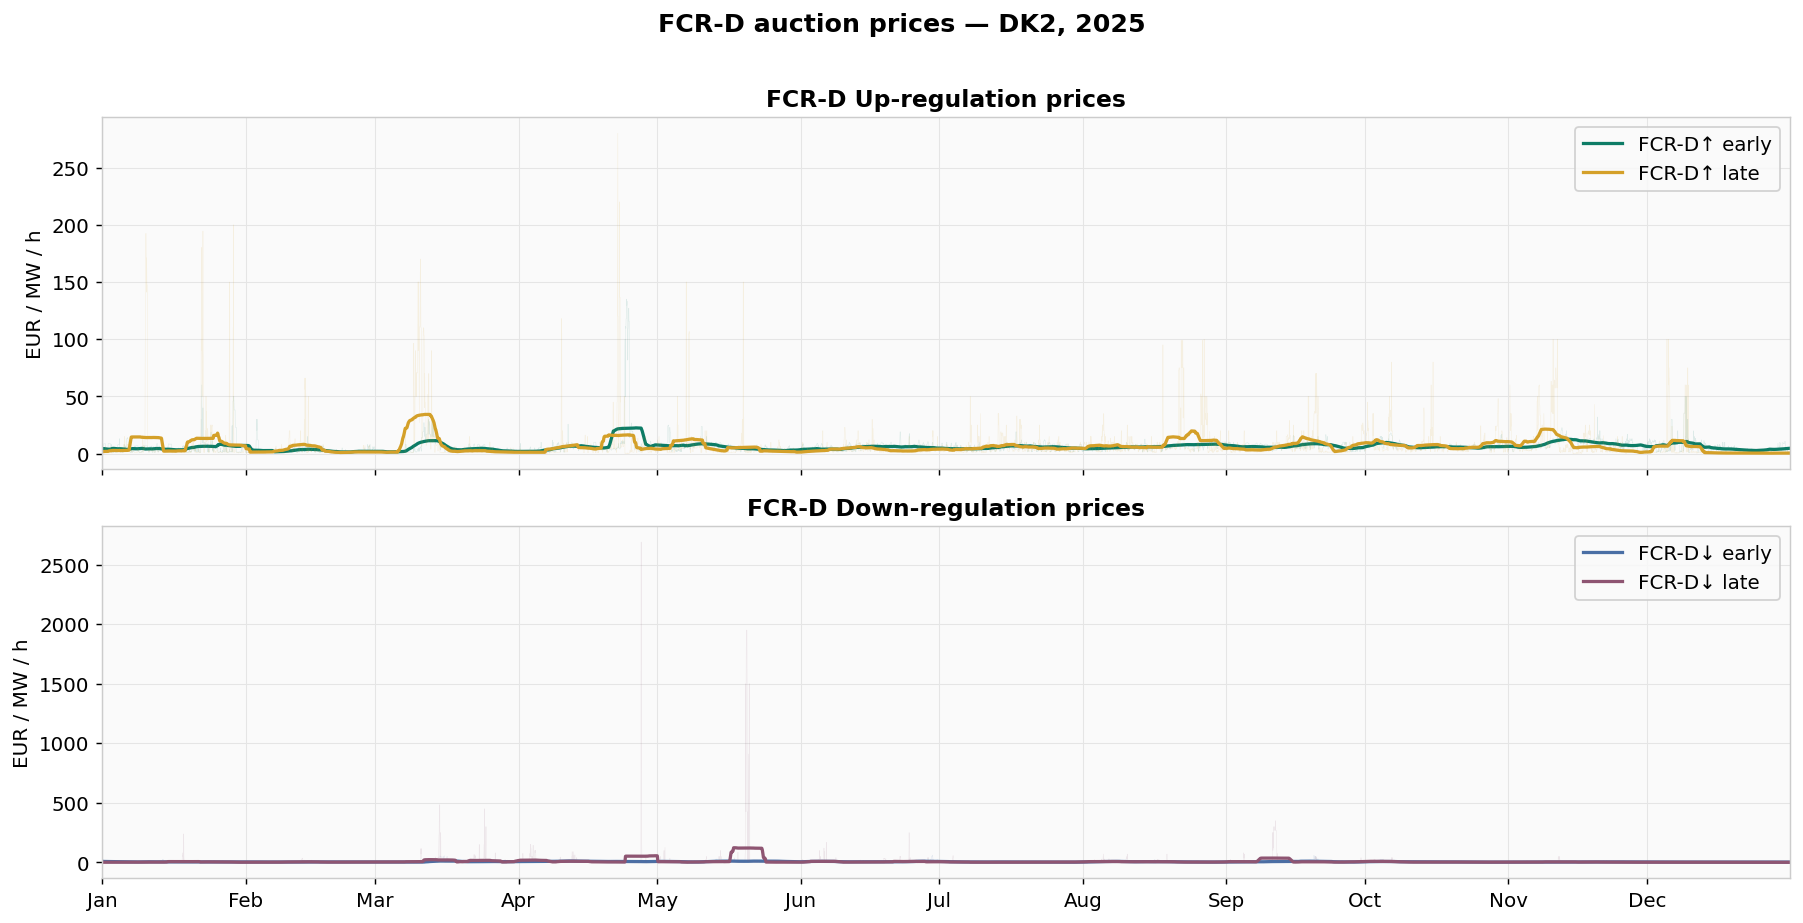

In [23]:
# Filter to relevant products & auctions (exclude 'Total')
fcrd_auctions = fcrd[fcrd['AuctionType'] != 'Total'].copy()

combos = [
    ('FCR-D upp', 'D-1 early', 'FCR-D\u2191 early',  C[0]),
    ('FCR-D upp', 'D-1 late',  'FCR-D\u2191 late',   C[4]),
    ('FCR-D ned', 'D-1 early', 'FCR-D\u2193 early',  C[2]),
    ('FCR-D ned', 'D-1 late',  'FCR-D\u2193 late',   C[3]),
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for prod, auc, label, col in combos[:2]:
    sub = fcrd_auctions[(fcrd_auctions['ProductName']==prod) &
                        (fcrd_auctions['AuctionType']==auc)]
    sub_s = sub['PriceTotalEUR']
    roll = sub_s.rolling(24*7, center=True, min_periods=24).mean()
    ax = axes[0]
    ax.plot(sub.index, sub_s.values, alpha=0.12, color=col, linewidth=0.3)
    ax.plot(roll.index, roll.values, color=col, linewidth=1.8, label=label)

axes[0].set_ylabel('EUR / MW / h')
axes[0].set_title('FCR-D Up-regulation prices')
axes[0].legend()

for prod, auc, label, col in combos[2:]:
    sub = fcrd_auctions[(fcrd_auctions['ProductName']==prod) &
                        (fcrd_auctions['AuctionType']==auc)]
    sub_s = sub['PriceTotalEUR']
    roll = sub_s.rolling(24*7, center=True, min_periods=24).mean()
    ax = axes[1]
    ax.plot(sub.index, sub_s.values, alpha=0.12, color=col, linewidth=0.3)
    ax.plot(roll.index, roll.values, color=col, linewidth=1.8, label=label)

axes[1].set_ylabel('EUR / MW / h')
axes[1].set_title('FCR-D Down-regulation prices')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.margins(x=0)

fig.suptitle('FCR-D auction prices — DK2, 2025', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


### 5.1 — FCR-D price statistics

In [24]:
stats_rows = []
for prod, auc, label, _ in combos:
    sub = fcrd_auctions[(fcrd_auctions['ProductName']==prod) &
                        (fcrd_auctions['AuctionType']==auc)]['PriceTotalEUR']
    stats_rows.append({
        'Product': label,
        'Mean (EUR)': sub.mean(),
        'Median (EUR)': sub.median(),
        'Std (EUR)': sub.std(),
        'Max (EUR)': sub.max(),
        'Zero-price hours (%)': 100 * (sub == 0).sum() / len(sub)
    })
stats_df = pd.DataFrame(stats_rows).set_index('Product')
display(stats_df.round(2))


,Mean (EUR),Median (EUR),Std (EUR),Max (EUR),Zero-price hours (%)
Product,,,,,
FCR-D↑ early,5.87,5.00,6.89,135.0,0.0
FCR-D↑ late,6.37,2.50,15.61,280.0,0.0
FCR-D↓ early,4.92,3.79,4.88,60.0,0.0
FCR-D↓ late,8.18,1.50,79.40,2690.0,0.0


### 5.2 — FCR-D price by hour of day

The intraday price profile for FCR-D reveals when reserve capacity is most valuable.

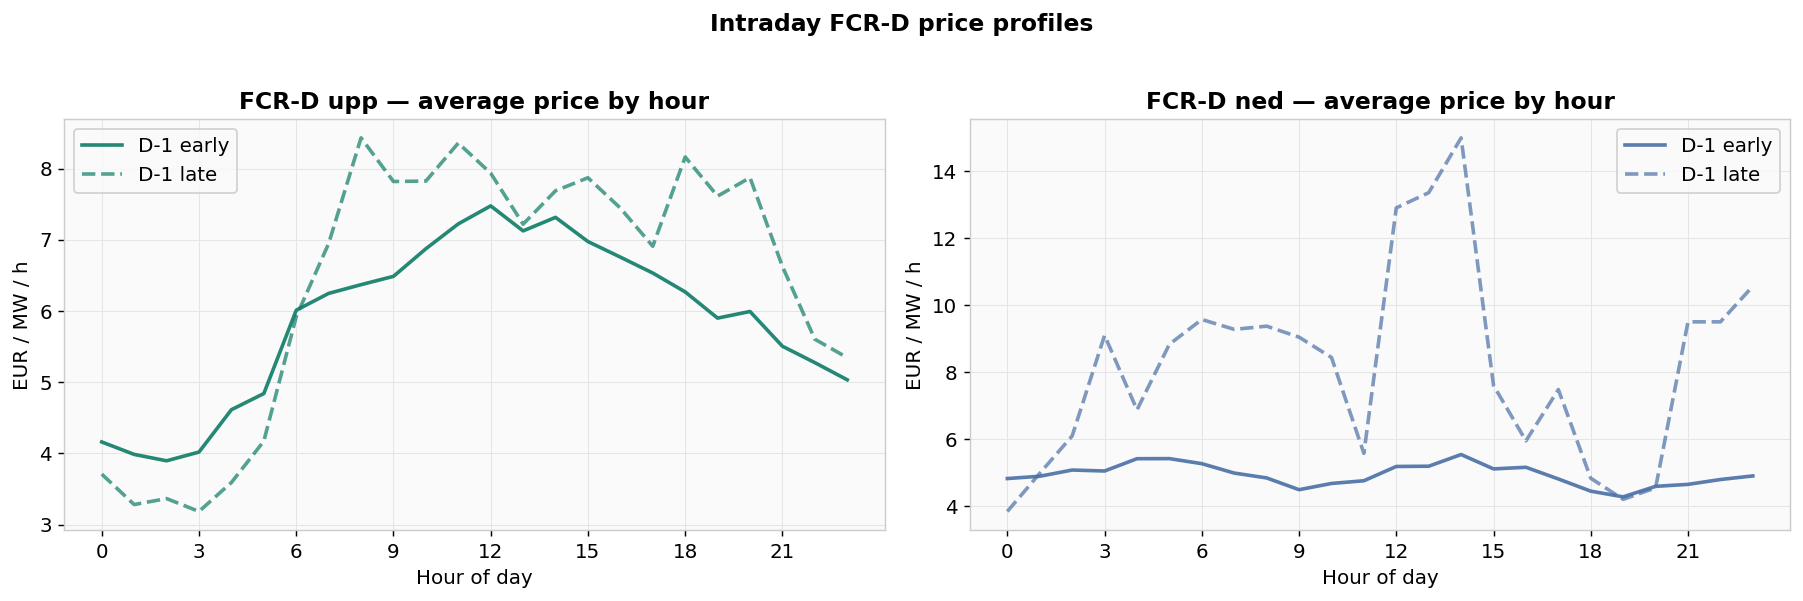

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for i, direction in enumerate(['FCR-D upp', 'FCR-D ned']):
    ax = axes[i]
    for auc, ls, alpha in [('D-1 early', '-', 0.9), ('D-1 late', '--', 0.7)]:
        sub = fcrd_auctions[(fcrd_auctions['ProductName']==direction) &
                            (fcrd_auctions['AuctionType']==auc)].copy()
        sub['hour'] = sub.index.hour
        profile = sub.groupby('hour')['PriceTotalEUR'].mean()
        color = C[0] if direction == 'FCR-D upp' else C[2]
        ax.plot(profile.index, profile.values, color=color, linewidth=2,
                linestyle=ls, alpha=alpha, label=auc)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('EUR / MW / h')
    ax.set_title(f'{direction} — average price by hour')
    ax.legend()
    ax.set_xticks(range(0, 24, 3))

fig.suptitle('Intraday FCR-D price profiles', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


### 5.3 — FCR-D monthly revenue potential

A simple back-of-envelope: if you reserved 1 MW for every hour of each month, what would the total payment be?

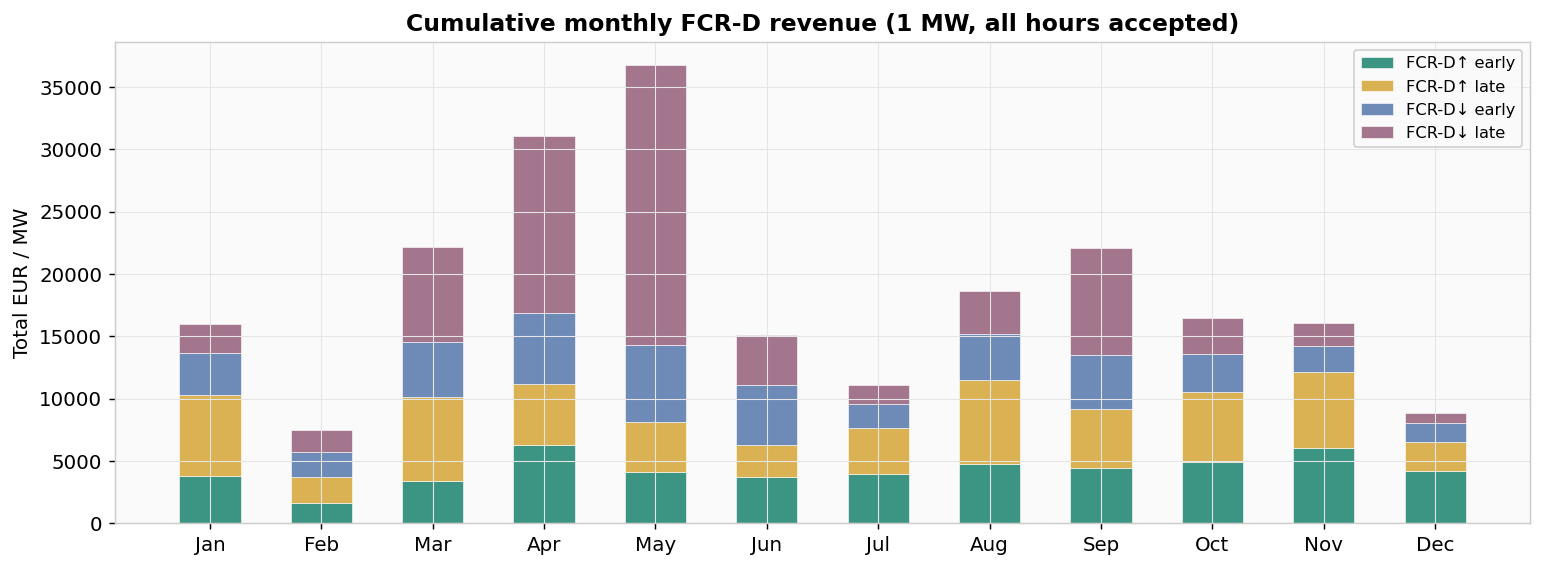

Total potential FCR-D revenue for 1 MW over 2025: EUR 665,552


In [26]:
fig, ax = plt.subplots(figsize=(12, 4.5))

bottom = np.zeros(12)
width = 0.55
months_idx = range(1, 13)

for prod, auc, label, col in combos:
    sub = fcrd_auctions[(fcrd_auctions['ProductName']==prod) &
                        (fcrd_auctions['AuctionType']==auc)].copy()
    sub['month'] = sub.index.month
    monthly_rev = sub.groupby('month')['PriceTotalEUR'].sum()
    monthly_rev = monthly_rev.reindex(months_idx, fill_value=0)
    ax.bar(months_idx, monthly_rev.values, width, bottom=bottom,
           color=col, alpha=0.8, label=label, edgecolor='white', linewidth=0.4)
    bottom += monthly_rev.values

ax.set_xticks(list(months_idx))
ax.set_xticklabels([calendar.month_abbr[m] for m in months_idx])
ax.set_ylabel('Total EUR / MW')
ax.set_title('Cumulative monthly FCR-D revenue (1 MW, all hours accepted)',
             fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()

total = fcrd_auctions['PriceTotalEUR'].sum()
print(f"Total potential FCR-D revenue for 1 MW over 2025: EUR {total:,.0f}")


---
## 6 — Cross-dataset relationships

Finally, we overlay the energy community's net load with the spot price to see whether price signals and community flexibility naturally align.

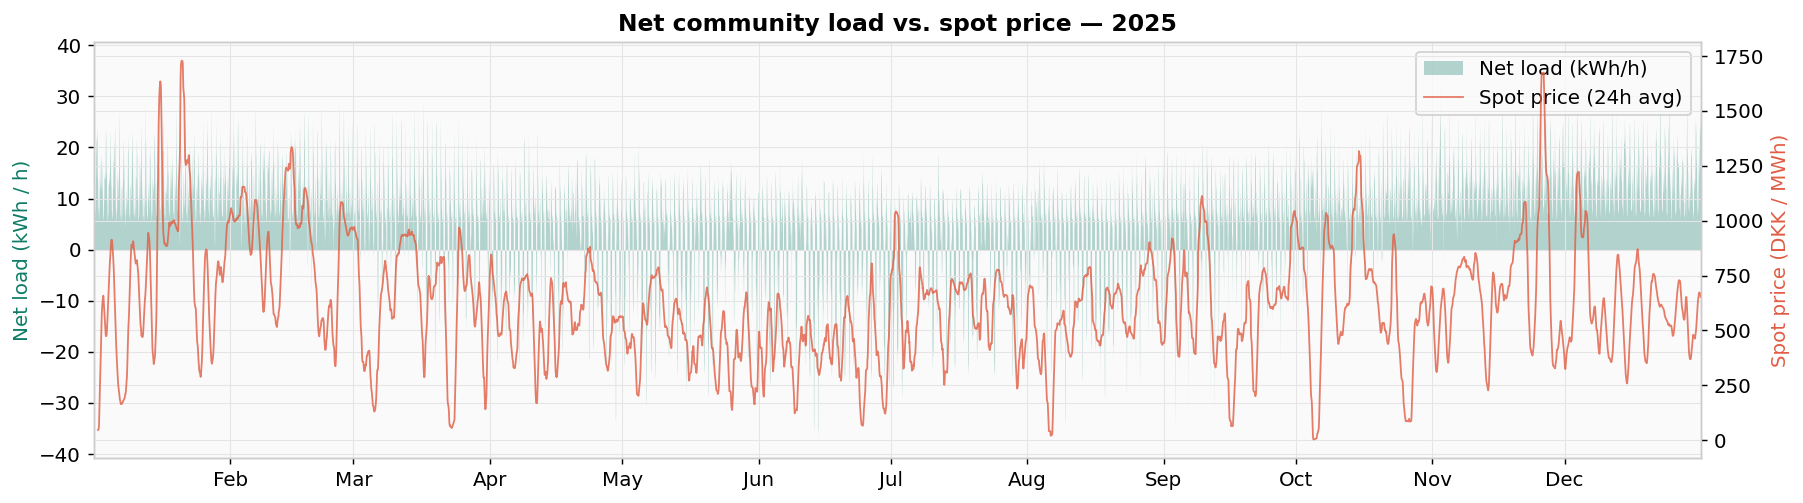

In [27]:
aligned = pd.DataFrame({
    'net_load': net_load,
    'spot': spot_full['SpotPriceDKK']
}).dropna()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()

ax1.fill_between(aligned.index, aligned['net_load'], alpha=0.3, color=C[0],
                 linewidth=0, label='Net load (kWh/h)')
ax2.plot(aligned['spot'].rolling(24).mean(), color=C[1], linewidth=1,
         alpha=0.8, label='Spot price (24h avg)')

ax1.set_ylabel('Net load (kWh / h)', color=C[0])
ax2.set_ylabel('Spot price (DKK / MWh)', color=C[1])
ax1.set_title('Net community load vs. spot price — 2025', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.margins(x=0)
fig.tight_layout()
plt.show()


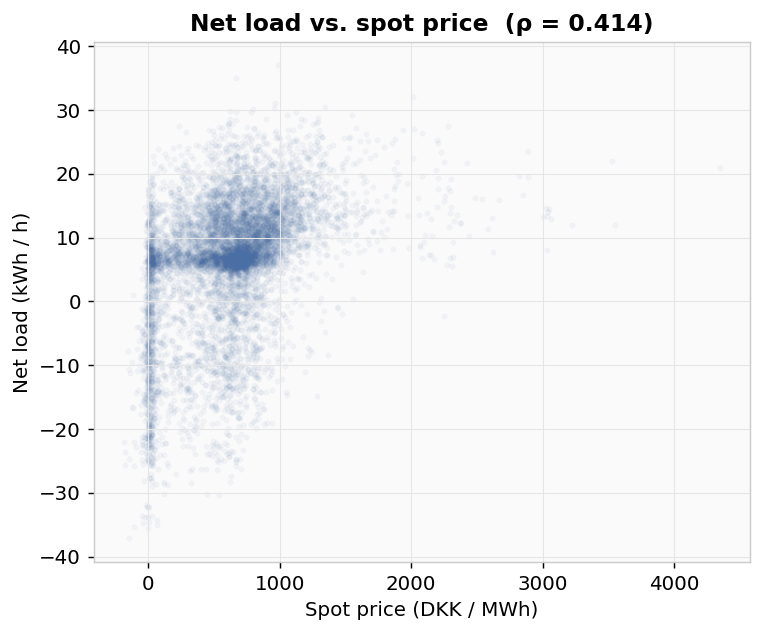

Pearson correlation between net load and spot price: 0.414


In [28]:
corr = aligned[['net_load', 'spot']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(aligned['spot'], aligned['net_load'], alpha=0.04, s=6, color=C[2])
ax.set_xlabel('Spot price (DKK / MWh)')
ax.set_ylabel('Net load (kWh / h)')
ax.set_title(f'Net load vs. spot price  (\u03C1 = {corr:.3f})', fontweight='bold')
fig.tight_layout()
plt.show()

print(f"Pearson correlation between net load and spot price: {corr:.3f}")


---
## 7 — Key takeaways

1. **Strong PV seasonality** — production is concentrated in spring/summer daylight hours, creating a pronounced seasonal mismatch with demand that persists year-round.

2. **Evening demand peak at 17–20h** — consistent with residential patterns. This peak coincides with declining PV output, making battery discharge particularly valuable.

3. **Spot prices follow demand** — the intraday price curve peaks in the morning and evening, roughly mirroring residential load patterns.

4. **FCR-D prices are volatile** — with significant zero-price hours but occasional high-value spikes. Up-regulation tends to command higher prices than down-regulation.

5. **Cross-dataset alignment** — the overlap between surplus PV hours (cheap/negative prices) and high-demand hours (expensive prices) defines the arbitrage window that the optimisation model must exploit.